#**Solución general de la ecuación de Lane-Emden para diferentes valores de n**

Para n = 1, la primera raíz aproximada de θ(x) se encuentra cerca de x = 3.1400


<ipython-input-1-0473160f75c6>:19: RuntimeWarning: invalid value encountered in scalar power
  d2theta = - theta**n - (2.0/x)*dtheta


Para n = 1.5, la primera raíz aproximada de θ(x) se encuentra cerca de x = 3.6500
Para n = 2, la primera raíz aproximada de θ(x) se encuentra cerca de x = 4.3500
Para n = 2.5 no se encontró cruce de θ(x) = 0 en el intervalo considerado.
Para n = 3, la primera raíz aproximada de θ(x) se encuentra cerca de x = 6.8950
Para n = 3.5 no se encontró cruce de θ(x) = 0 en el intervalo considerado.
Para n = 4 no se encontró cruce de θ(x) = 0 en el intervalo considerado.
Para n = 5 no se encontró cruce de θ(x) = 0 en el intervalo considerado.


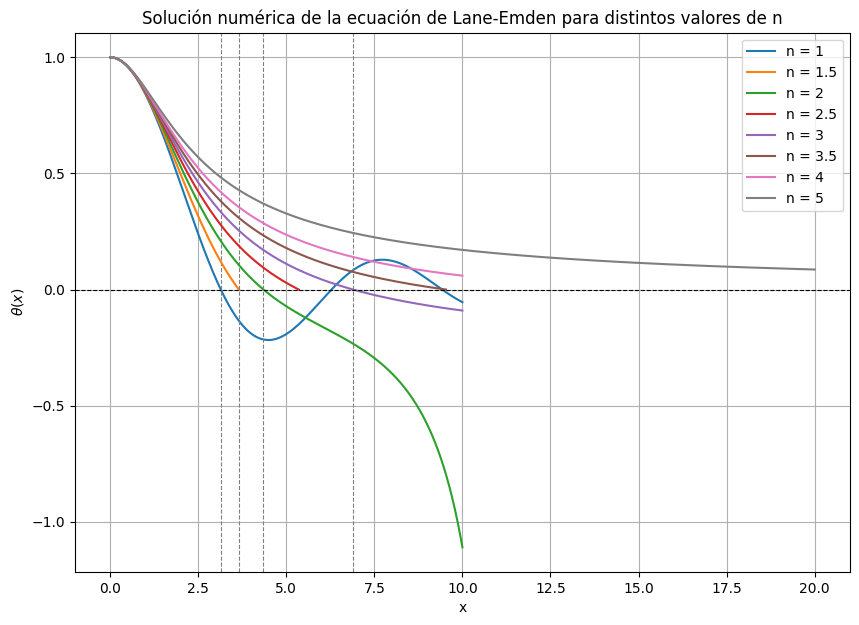

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la función que genera el sistema de Lane-Emden para un índice politrópico dado n
def lane_emden(n):
    """
    Devuelve la función que representa el sistema:
      y[0] = theta(x)
      y[1] = dtheta/dx
    tal que:
      dtheta/dx = y[1]
      d^2theta/dx^2 = - theta^n - (2/x)*dtheta/dx
    """
    def f(x, y):
        theta, dtheta = y  # desempaquetamos
        # Para evitar la singularidad en x = 0
        if np.isclose(x, 0.0):
            return np.array([dtheta, 0.0])
        d2theta = - theta**n - (2.0/x)*dtheta
        return np.array([dtheta, d2theta])
    return f

# 2. Método de Runge-Kutta de 4º orden para un paso
def rk4_step(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + (h/2)*k1)
    k3 = f(x + h/2, y + (h/2)*k2)
    k4 = f(x + h,   y + h*k3)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# 3. Solución de la EDO mediante RK4 en un intervalo [x0, x1]
def solve_ode_rk4(f, x0, x1, y0, N):
    """
    f   : función que define el sistema (retornado por lane_emden)
    x0  : valor inicial de x
    x1  : valor final de x
    y0  : vector de condiciones iniciales [theta(x0), dtheta/dx(x0)]
    N   : número de pasos
    """
    x_vals = np.linspace(x0, x1, N+1)
    h = (x1 - x0)/N
    sol = np.zeros((N+1, len(y0)))
    sol[0] = y0

    for i in range(N):
        sol[i+1] = rk4_step(f, x_vals[i], sol[i], h)

    return x_vals, sol

# 4. Configuración de parámetros comunes
x_min = 1e-6  # para evitar la singularidad en x = 0
# Se escoge un x_max suficientemente grande. Para n=5 la solución decae lentamente,
# así que se usa un valor mayor. Usaremos x_max = 10 para n <= 4 y x_max = 20 para n=5.
N = 2000      # número de pasos
y0 = np.array([1.0, 0.0])  # condiciones iniciales: theta(0)=1, theta'(0)=0

# 5. Lista de índices politrópicos a resolver
n_values = [1, 1.5, 2, 2.5, 3, 3.5, 4, 5]

# Preparar figura para graficar
plt.figure(figsize=(10, 7))

# Iterar sobre los diferentes valores de n
for n in n_values:
    f = lane_emden(n)
    # Elegir x_max según n
    x_max = 10.0 if n < 5 else 20.0

    x_vals, sol = solve_ode_rk4(f, x_min, x_max, y0, N)
    theta_vals = sol[:, 0]

    # Buscar la primera raíz, si existe (cambio de signo en theta)
    x_cross = None
    for i in range(len(theta_vals)-1):
        if theta_vals[i] * theta_vals[i+1] < 0:
            # Aproximamos la raíz tomando el valor de x del cruce
            x_cross = x_vals[i]
            break

    # Graficar la solución para cada n
    plt.plot(x_vals, theta_vals, label=f'n = {n}')
    if x_cross is not None:
        plt.axvline(x_cross, color='gray', linestyle='--', linewidth=0.8)
        print(f"Para n = {n}, la primera raíz aproximada de θ(x) se encuentra cerca de x = {x_cross:.4f}")
    else:
        print(f"Para n = {n} no se encontró cruce de θ(x) = 0 en el intervalo considerado.")

# Agregar elementos al gráfico
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.title('Solución numérica de la ecuación de Lane-Emden para distintos valores de n')
plt.xlabel('x')
plt.ylabel(r'$\theta(x)$')
plt.grid(True)
plt.legend()
plt.show()


# **Formulación de la ecuación de Lane-Emden para un modelo Politropico del Sol (actual) para n = 3**

Dada la ecuación obtenida de la combinar las anteriores ecuaciones:

\begin{equation}
  \frac{d}{dr}\left ( \frac{r^{2}}{\rho^{2/3}}\frac{d\rho }{dr} \right )=-\frac{3\pi G}{K}r^{2}\rho,
\end{equation}

cuyas condiciones de contorno son:
\begin{equation}  \rho (0)=\rho _{0} \quad \text{y} \quad \rho (R)=0,  \end{equation}

donde $\rho _{0}$ y $R$ es la densidad en el nucleo y el radio de la estrella respectivamente.

Ahora, haciendo un cambio de funcion conveniente

\begin{equation}
  \rho (r)=\rho _{0}\theta ^{3}(r),
\end{equation}

obtenemos lo siguiente
\begin{equation}
  \frac{r^{2}}{\rho^{2/3}}\frac{d\rho }{dr}=\frac{r^{2}}{\rho_{0}^{2/3}\theta ^{2}}\left ( 3\rho _{0}\theta ^{2}\frac{d\theta }{dr} \right )\quad \text{y} \quad -\frac{3\pi G}{K}r^{2}\rho = -\frac{3\pi G}{K}r^{2}\rho_{0}\theta ^{3}
\end{equation}

reemplazando en la primera ecuación tenemos

\begin{equation}
  \frac{d}{dr}\left [\frac{r^{2}}{\rho_{0}^{2/3}\theta ^{2}}\left ( 3\rho _{0}\theta ^{2}\frac{d\theta }{dr} \right )\right ]=-\frac{3\pi G}{K}r^{2}\rho_{0}\theta ^{3}
\end{equation}

reorganizando los terminos se tiene,

\begin{equation}
  \frac{d}{dr}\left [r^{2} \frac{d\theta }{dr}\right ]=-\frac{\pi G \rho_{0}^{2/3}}{K}r^{2}\theta ^{3}.
\end{equation}

Haciendo el cambio de variable
\begin{equation}  
  x=r/r_{0} \quad \text{donde} \quad  r_{0}=\left ( \frac{K}{\pi G\rho_{0}^{2/3}}  \right )^{1/2},  
\end{equation}
aplicando regla de la cadena se obtiene las expresiones


\begin{equation}
  \frac{d\theta }{dx}=\frac{d\theta }{dr}\frac{dr}{dx}=\frac{d\theta }{dr}r_{0} \quad \text{y} \quad \frac{d }{dr}=\frac{1}{r_{0}}\frac{d}{dx},
\end{equation}


reemplazando en la ecuación (3) se tiene


\begin{equation}
  \frac{1}{r_{0}}\frac{d}{dx}\left ( r_{0}^{2}x^{2}\frac{1}{r_{0}}\frac{d\theta }{dx} \right )=-x^{2}\theta ^{3},
\end{equation}


simplificando llegamos a la ecuación


\begin{equation}
  \frac{1}{x^{2}}\frac{d}{dx}\left ( x^{2}\frac{d\theta }{dx} \right )=-\theta ^{3}.
\end{equation}

**Resolución de la ecuación de Lane-Emden para $n=3$ con Runge-Kutta 4**

La ecuación de Lane-Emden para $n=3$ se escribe habitualmente como

\begin{equation}
  \frac{1}{x^{2}}\frac{d}{dx}\left ( x^{2}\frac{d\theta }{dx} \right )=-\theta ^{3}
\end{equation}

con las condiciones de contorno:
\begin{equation}
\theta(0) = 1,
\quad
\left.\frac{d\theta}{dx}\right|_{x=0} = 0.
\end{equation}

El problema se resuelve desde $x=0$ hasta el primer valor $x = x_1$ tal que $\theta(x_1)=0$. Para $n=3$, se sabe que $x_1 \approx 6.8968$.

**Reescritura como sistema de primer orden**

Definimos las variables:

\begin{equation}
y_1 = \theta,
\quad
y_2 = \frac{d\theta}{dx}.
\end{equation}

La ecuación original
\begin{equation}
  \frac{1}{x^{2}}\frac{d}{dx}\left ( x^{2}\frac{d\theta }{dx} \right )=-\theta ^{3}.
\end{equation}

se convierte en
\begin{equation}
\frac{d}{dx}\bigl(x^2 y_2\bigr) = -\,x^2 \,y_1^3,
\end{equation}

que, al desarrollar la derivada, da:
\begin{equation}
x^2 \frac{dy_2}{dx} + 2x\,y_2 = -\,x^2 \,y_1^3.
\end{equation}

Por lo tanto,
\begin{equation}
\frac{dy_2}{dx} = -\,y_1^3 \;-\; \frac{2}{x}\,y_2.
\end{equation}

El sistema de primer orden queda:
\begin{equation}
\begin{cases}
\dfrac{dy_1}{dx} = y_2,\\[6pt]
\dfrac{dy_2}{dx} = -\,y_1^3 - \dfrac{2}{x}\,y_2.
\end{cases}
\end{equation}

Las condiciones iniciales son $\theta(0)=1$ y $\theta'(0)=0$, pero existe una singularidad aparente en $x=0$ por el término $2/x$. Para manejarla numéricamente, se acostumbra:


Usar una expansión en serie cerca de $x=0$, o

Comenzar la integración en un valor muy pequeño $x_\mathrm{min}>0$, por ejemplo $x_\mathrm{min} = 10^{-6}$.

**Código en Python usando Runge-Kutta 4**

El siguiente código:

1.   Define la función que describe el sistema (``lane\_emden\_n3``).
2.   Integra desde $x = x_\mathrm{min}$ hasta un $x_\mathrm{max}$ (suficiente para contener la raíz $\approx 6.8968$).
3.  Almacena la solución y localiza dónde $\theta$ se anula.
4.  Grafica la función $\theta(x)$.



La primera raíz aproximada de theta(x) está cerca de x = 6.8950


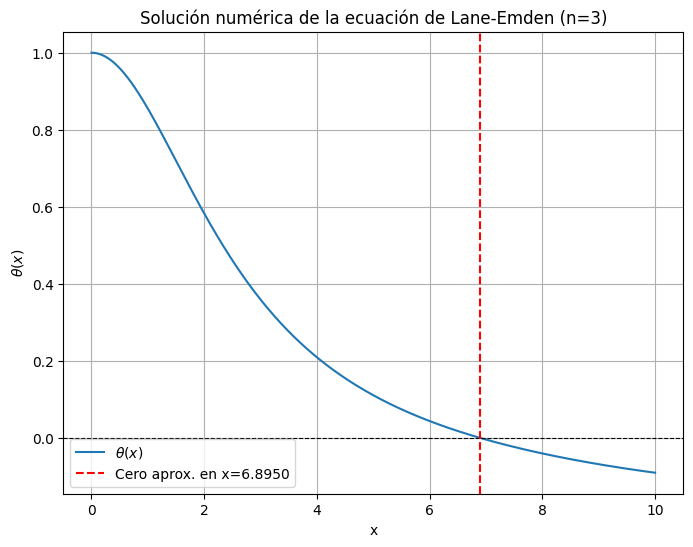

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el sistema Lane-Emden (n=3)
# Esto define una función llamada lane_emden_n3 que toma dos argumentos: x (la variable independiente) e y (un vector que contiene theta(x) y su derivada dtheta/dx).
def lane_emden_n3(x, y):
    """y[0] = theta(x), y[1] = dtheta/dx
       Retorna dy/dx = [ dtheta/dx, d^2theta/dx^2 ]
    """
    # Estas líneas extraen theta(x) y dtheta/dx del vector y.
    theta = y[0]
    dtheta = y[1]

    # Para x muy cerca de 0, evitar la singularidad 2/x
    # (suponemos que arrancamos en x_min>0)
    if np.isclose(x, 0.0): # Si x está muy cerca de 0,
        return np.array([dtheta, 0.0]) #Se devuelve un arreglo de NumPy con los valores [dtheta, 0.0].

    # Ecuación Lane-Emden: d^2theta/dx^2 = - theta^3 - 2/x * dtheta/dx
    d2theta = - theta**3 - (2.0/x)*dtheta   # Esto calcula la segunda derivada de theta
    return np.array([dtheta, d2theta])      # Devuelve un arreglo con los valores de la primera y segunda derivada

# 2. Esta función implementa un solo paso del método de Runge-Kutta de cuarto orden.
    """Toma la función f que define el sistema de ecuaciones,
       el valor actual de x, los valores actuales de las variables dependientes y y el tamaño del paso h.
       Devuelve los valores actualizados de y después de un paso."""
def rk4_step(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + (h/2)*k1)
    k3 = f(x + h/2, y + (h/2)*k2)
    k4 = f(x + h,   y + h*k3)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# 3. solución EDO
    """ Esta función utiliza la función rk4_step para resolver el sistema de EDO en un rango de valores de x."""
def solve_ode_rk4(f, x0, x1, y0, N):
    """
    f   : función que define el sistema (lane_emden_n3)
    x0  : valor inicial de x
    x1  : valor final de x
    y0  : vector de condiciones iniciales [theta(x0), dtheta/dx(x0)]
    N   : número de pasos
    """
    x_vals = np.linspace(x0, x1, N+1) # Crea una vector de valores de x usando np.linspace.
    h = (x1 - x0)/N                   # Tamaño del paso

    sol = np.zeros((N+1, len(y0))) # Crea una matriz de ceros (N+1 filas, longitud(y0) columnas, osea 2001x2) para almacenar la solución en cada valor de x.
    sol[0] = y0                    # Almacena en la primera posición de la matriz, las condiciones para x tendiendo a cero

    for i in range(N): # Itera a través de los valores de x, aplicando la función rk4_step para actualizar la solución.
        sol[i+1] = rk4_step(f, x_vals[i], sol[i], h)

    return x_vals, sol # Devuelve el vector de x y la matriz de las soluciones correspondientes para theta(x) {columna 1} y dtheta(x)/dx {columna 2}.

# 4. Parámetros de la integración
x_min = 1e-6  # para evitar la singularidad en x=0
x_max = 10.0  # suficientemente grande para cubrir la raíz ~6.8968
N = 2000      # número de pasos

# Condiciones iniciales "casi" en x=0
theta0 = 1.0
dtheta0 = 0.0
y0 = np.array([theta0, dtheta0])

# 5. Se llama a la función solve_ode_rk4 con la función de Lane-Emden y los parámetros de integración para obtener la solución numérica.
x_vals, sol = solve_ode_rk4(lane_emden_n3, x_min, x_max, y0, N)

# sol[:,0] = theta(x)
# sol[:,1] = dtheta/dx
theta_vals = sol[:,0] # Se define el vector de valores obtenidos de theta(x) despues de la solucion (primera columna de sol).

# 6. Buscamos la primera raíz de theta
# Queremos el x donde theta se hace 0 (cambia de signo). Recorremos y buscamos el primer cruce.
zero_index = None                           # Inicializa zero_index como None, indicando que aún no se ha encontrado un cruce.
for i in range(len(theta_vals)-1):          # Recorre la lista theta_vals, que contiene los valores de la función θ(x) evaluados en diferentes puntos.
    if theta_vals[i] * theta_vals[i+1] < 0: # Verifica si hay un cambio de signo entre dos valores consecutivos
        zero_index = i                      # Si θ(x) cambia de signo (producto negativo), significa que en ese intervalo la función cruzó el eje x.
        break                               # Guarda el índice i del primer cruce y sale del bucle

if zero_index is not None:            # Si se encuentra un cruce, se aproxima la raíz:
    x_cross = x_vals[zero_index]      # Usa zero_index para tomar el valor de x en ese punto (x_cross = x_vals[zero_index]).
    print(f"La primera raíz aproximada de theta(x) está cerca de x = {x_cross:.4f}")
else:                                 # Si zero_index sigue siendo None, significa que no hubo cambio de signo en todo el intervalo.
    print("No se encontró cruce de theta(x)=0 en el intervalo dado.")

# 7. Graficar la solución
plt.figure(figsize=(8,6))
plt.plot(x_vals, theta_vals, label=r'$\theta(x)$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8) #Esto agrega una línea discontinua horizontal en y = 0 para representar el eje x.
if zero_index is not None:
    plt.axvline(x_cross, color='r', linestyle='--', label=f'Cero aprox. en x={x_cross:.4f}')
plt.title('Solución numérica de la ecuación de Lane-Emden (n=3)')
plt.xlabel('x')
plt.ylabel(r'$\theta(x)$')
plt.grid(True)
plt.legend()
plt.show()

**Estudio de las condiciones de Contorno**

Dado los cambios de variables realizados

\begin{equation}  
  x=r/r_{0} \quad \text{donde} \quad  r_{0}=\left ( \frac{K}{\pi G\rho_{0}^{2/3}}  \right )^{1/2},  
\end{equation}

\begin{equation}
  \rho (r)=\rho _{0}\theta ^{3}(r),
\end{equation}

cuyas condiciones de contorno iniciales para $\rho=\rho(r)$ son:

\begin{equation}  \rho (0)=\rho _{0} \quad \text{y} \quad \rho (R)=0,  \end{equation}

donde $\rho _{0}$ y $R$, es la densidad en el nucleo y el radio de la estrella respectivamente.

Debemos asegurar que al volver a nuestras variables originales, estas condiciones se sigan manteniendo, por lo que es necesario estudiarlas a detalle.

Primero revisemos si las condiciones habituales de la ecuación de Lane-Emdem cumplen con nuestras condiciones iniciales:

Partimos de $\rho (r)=\rho _{0}\theta ^{3}(r)$ y evaluamos en $r=0$ y $r=R$,

Para $r=0$:
\begin{equation}
   \rho (0)=\rho _{0}\theta ^{3}(0)=\rho _{0}\to \theta ^{3}(0)=1\to \theta(r=0)=1
\end{equation}

Para $r=R$:
\begin{equation}
  \rho (R)=\rho _{0}\theta ^{3}(R)=0\to\theta ^{3}(R)=0 \to \theta(r=R)=0,
\end{equation}

Ahora tenemos el cuenta el cambio $x=r/r_{0}$, por lo tanto las condiciones de contorno se convierten en,

Para $r=0 \to x=0$:
\begin{equation}
   \rho (r=0)\to \theta(x=0)=1.
\end{equation}

Para $r=R \to x=R/r_{0} $:
\begin{equation}
  \rho (r=R) \to \theta(x=R/r_{0})=0,
\end{equation}

Ahora recordemos que habitualmente $\theta(x)$ se anula en la primera raiz $x_{1}\approx 6.89$ y dado la segunda condición, se tiene que:

\begin{equation}
  \theta(x=x_{1})= \theta(x=R/r_{0})=0,
\end{equation}

Por lo tanto, se impone que $x_{1}=R/r_{0}$, esto se traduce en una restricción para $R=x_{1}r_{0}$ al ser evaluado en $\theta(r)$, es decir, se debe cumplir que

\begin{equation}
  \theta(r=R)=\theta(r=x_{1}r_{0})=0
\end{equation}

Teniendo en cuenta que para este caso $ r_{0}=7.31805 \cdot 10^{7}$, se tiene que numericamente

\begin{equation}
\theta(r=x_{1}r_{0}) = \theta(r=5.0458 \cdot 10^{8})=0.
\end{equation}

Esto se puede comprobar en la grafica $\theta(r)$, con esto se verifica nuestra condición $\rho(R)=0$

La primera raíz aproximada de θ(r) está en r ≈ 5.0458e+08 m que corresponde con la condición 6.89*r0


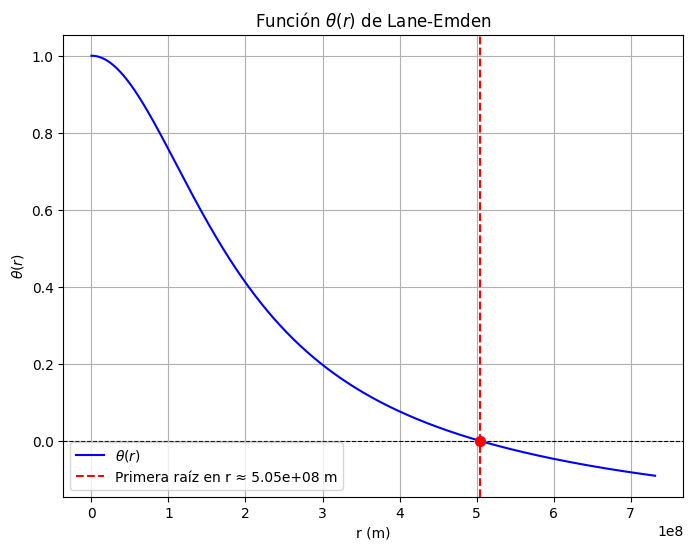

In [ ]:
#VERIFICACIÓN DE LAS CONDICIONES DE CONTORNO.
# Valor dado para r_0
r_0 = 7.31805e7

# Transformación de la variable x a r
r_vals = x_vals * r_0  # Convertimos x a r usando la relación r = x * r_0

# Encontrar la primera raíz de theta(r)
zero_indices = np.where(np.diff(np.sign(theta_vals)))[0]  # Índices donde theta cambia de signo

if len(zero_indices) > 0:
    first_zero_index = zero_indices[0]  # Primera raíz encontrada
    r_cross = r_vals[first_zero_index]   # Convertimos el índice en el valor de r
    print(f"La primera raíz aproximada de θ(r) está en r ≈ {r_cross:.4e} m que corresponde con la condición 6.89*r0")
else:
    r_cross = None
    print("No se encontró un cruce de θ(r) = 0 en el intervalo dado.")

# Graficar theta(r)
plt.figure(figsize=(8,6))
plt.plot(r_vals, theta_vals, label=r'$\theta(r)$', color='b')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)  # Línea horizontal en y=0
# Si se encontró la raíz, la marcamos en la gráfica
if r_cross is not None:
    plt.axvline(r_cross, color='r', linestyle='--', label=f'Primera raíz en r ≈ {r_cross:.2e} m')
    plt.scatter(r_cross, 0, color='r', s=50, zorder=3)  # Punto rojo en la raíz
plt.xlabel('r (m)')
plt.ylabel(r'$\theta(r)$')
plt.title('Función $θ(r)$ de Lane-Emden')
plt.grid(True)
plt.legend()
plt.show()


#Condiciones iniciales para las variables a estudiar.

Es importante hacer un estudio físico de las condiciones inciales para nuestro problema. Para ello definiremos algunos de los parametros que se requieren.
\begin{aligned}
M(r=0) &= 0, \quad & M(r=R) &= \mathcal{M},\\
P(r=0) &= P_{0}, \quad & P(r=R) &= 0,\\
T(r=0) &= T_{0}, \quad & T(r=R) &= 0,\\
\rho(r=0) &= \rho_{0}, \quad & \rho(r=R) &= 0.
\end{aligned}



Para esto usareos los valores de la literatura donde $P_{0} = 2.7$ X $10^{16} Pa$ y $\rho_{0} = 155000 \frac{Kg}{m^3}$

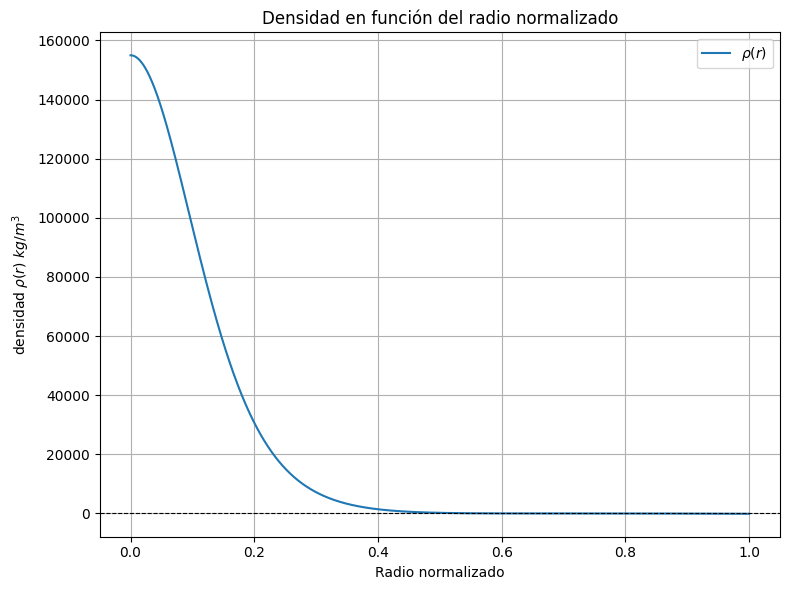

In [ ]:
# "Deshacer" el cambio de variable para rho(r)
r0=7.31805e7
rho0 = 1.55e5   # Densidad nucleo sol (Obtenida de la bilbiografía)
#R=6.9634e8
# Convertimos x --> r = r0 * x
r_vals = x_vals * r0
# Recordemos que hemos escogido un valor de n = 3 para la solución de la ecuación de Lane-Emden
# Recuperamos rho(r) = rho0 * [theta(r)]^3
rho_vals = rho0 * (theta_vals**3)

# Graficar resultados
plt.figure(figsize=(8,6))
plt.plot(r_vals/(10*r0), rho_vals, label=r'$\rho(r)$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel(r'densidad $\rho(r)$ $kg/m^3$')
plt.title('Densidad en función del radio normalizado')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
np.savetxt("r_vals.txt", r_vals)
np.savetxt("rho_vals.txt", rho_vals)

Esta grafica se corresponde de manera muy adecuada a las proporcionadas por la bibliografia, motivo por el cual, parece adecuado el valor de n = 3 como parámetro de solución para la ecuación de Lane-Emden.

#Ecuación diferencial de la masa en terminos de la densidad.

Recordemos que en la deducción de la ecuaciones de dinámica estelar, se obtuvo la siguiente ecuación diferencial:
\begin{equation} \frac{dM}{dr} = 4\pi r^{2}\rho(r)
\end{equation}

Para resolver la ecuación diferencial haremos uso de un código RK4, donde usaremos los valores de $\rho(r)$ obtenidos en el paso anterior.

Ahora, es una ecuación diferencial de primer orden, con lo cual necesitaremos una condición indicil, la cual, vendrá dada por el sentido físico de la ecuación a resolver, donde, si asumimos la masa como función del radio, es natural que $M(r=0) = 0$, que sería la masa en el punto singular del sol

[0.00000000e+00 3.18247244e+22 2.54515781e+23 ... 1.49413435e+30
 1.49385458e+30 1.49357362e+30]


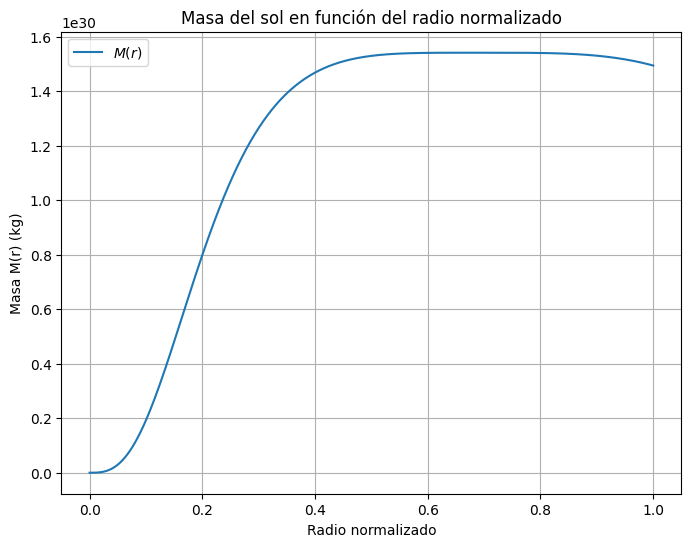

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos previos. Es necesario importarlos como txt para que no exista confusión en las variblaes
r_vals = np.loadtxt("r_vals.txt")
rho_vals = np.loadtxt("rho_vals.txt")

# Definir la ecuación diferencial
def mass_equation(r, M):
    rho_r = np.interp(r, r_vals, rho_vals)  # Antes de devolver la función que se usará para resolver el método RK, es necesario interpolar los datos de rho
    #esto con el objetivo de que, cuando se haga la discretización en el método RK, los valores de rho, queden dentro de los intervalos.
    return 4 * np.pi * r**2 * rho_r

# Implementar RK4 para resolver la ecuación
def solve_mass_rk4(r_vals, M0=0):
    M_vals = np.zeros_like(r_vals)
    M_vals[0] = M0

    for i in range(1, len(r_vals)):
        h = r_vals[i] - r_vals[i-1]
        k1 = mass_equation(r_vals[i-1], M_vals[i-1])
        k2 = mass_equation(r_vals[i-1] + h/2, M_vals[i-1] + h*k1/2)
        k3 = mass_equation(r_vals[i-1] + h/2, M_vals[i-1] + h*k2/2)
        k4 = mass_equation(r_vals[i-1] + h, M_vals[i-1] + h*k3)

        M_vals[i] = M_vals[i-1] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return M_vals

# Resolver la ecuación
M_vals = solve_mass_rk4(r_vals)
print(M_vals)
# Graficar la solución
plt.figure(figsize=(8,6))
plt.plot(r_vals/(10*r0), M_vals, label=r'$M(r)$')
plt.xlabel('Radio normalizado')
plt.ylabel('Masa M(r) (kg)')
plt.title('Masa del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()
np.savetxt("M_vals.txt", M_vals)

Observamos que la grafica obtenida se corresponde de manera optima a la gráfica que hemos asumido como teórica, no obstante, el límite superior, que es del orden de $2$x$10^{30} Kg$, en teoría, solo llega hasta el valor de $1,6$x$10^{30}Kg$.

Si bien la discrepancia no es muy grande, existe. Una posible razón es que hemos usado un valor de n = 3 para la ecuación de Lane-Emden. Como veremos mas adelante, este es el valor que mejor ajusta la grafica de presión, sin embargo, se paga el precio de no obtener valores mas exactos en otras cantidades como la masa, por ejemplo. Sin embargo, algo que nos deja tranquilos, es la correspondencia en el orden de magnitud de los datos obtenidos y la similitud en el perfil de la grafica.

#Codigo para encontrar la presión del modelo

Aquí abordaremos dos enfoques: \\
 **Primero**: Partiremos de la ecuación diferencial:
\begin{equation} \frac{dP}{dr} = \frac{-G M(r)\rho{(r)}}{r^{2}}
\end{equation}

Nuevamente, para ello usaremos lo datos de masa y densidad obtenidos en pasos anteriores y aplicaremos nuevamente un **RK4**. Para ello usaremos la condición de valor inicial $P(0) = 2.7$x$10^{16} Pa$, que es la propuesta en la bilbiografia.

**Segundo**: Este enfoque es mucho mas sencilo, puesto que usamos una aproximación conocida como:
# Aproximación de Eddington


Como se ha visto la gran utilidad de la ecuación de Lane-Emden, se busca que la parte radiativa preserve la naturaleza politrópica del modelo estelar. En este aspecto juega un papel la aproximación de Eddington. Eddington elimina la aproximación de ignorar la presión de radiación. En este modelo, la presión de la estrella consiste en la suma de la presión debida a la masa y la presión de radiación. Además, se añade la condición de que la presión de radiación sea proporcional a la presión total de la estrella. Así se tiene:

\begin{equation}
P = p_m + p_r
\quad \Longrightarrow \quad
\frac{p_r}{P} = 1 - b,
\end{equation}

donde $b$ es una constante menor que 1. Esta ligadura permite que la estrella permanezca politrópica, ya que:

\begin{equation}
P = \frac{p_m}{b}
\;=\; \frac{k_b\,T}{\mu\,b}\,\rho.
\end{equation}

A partir de ello, se obtiene:

\begin{equation}
p_r \;=\; \frac{p_m}{b} \;-\; p_m
\;=\; p_m\,\biggl(\frac{1-b}{b}\biggr).
\end{equation}

Ahora basta con calcular la presión de radiación . Para la presión de radiación suponemos que la estrella se comporta como un cuerpo negro, de modo que:

\begin{equation}
p_r \;=\; \frac{2}{c}\,\int_\nu I_\nu \cos^2\theta \, d\Omega
\;=\; \frac{\mu}{3}
\;=\; \frac{\sigma\,T^4}{3},
\end{equation}

donde $\mu$ es la intensidad específica (energía/superficie), $\theta$ aparece al integrar el flujo neto de energía que atraviesa una superficie en la dirección normal a ésta (y se usa además para hallar el momento del flujo), y $\sigma$ es la constante de Stefan-Boltzmann.

Sustituyendo los valores de $p_m$ se obtiene:
\begin{equation}
\frac{1}{3}\,\sigma\,T^4
\;=\; (1-b)\,\frac{k_b}{\mu\,b}\,\rho\,T.
\end{equation}

Resolviendo esta ecuación para $T$:

\begin{equation}
T
\;=\;
\Biggl[\frac{3\,k_b\,(1-b)}{\sigma\,\mu\,b}\Biggr]^{\!1/3}\,
\rho^{1/3}.
\end{equation}

Sustituyendo este resultado en la ecuación para la presión total, se tiene:

\begin{equation}
P
\;=\; \frac{k_b\,T}{\mu\,b}\,\rho
\;=\; \frac{k_b}{\mu\,b}
\Biggl[\frac{3\,k_b\,(1-b)}{\sigma\,\mu\,b}\Biggr]^{\!1/3}
\rho^{4/3}.
\end{equation}

Como el factor que precede a $\rho^{4/3}$ es una constante, podemos escribir:

\begin{equation}
P
\;=\; k\,\rho^{4/3},
\end{equation}

y de ello se deduce que la aproximación de Eddington conduce a un modelo politrópico con $\gamma = 4/3$ y $n = 3$.


<ipython-input-6-c75dee6c268c>:55: RuntimeWarning: invalid value encountered in power
  P_solution2 = k * rho_vals**(4/3)


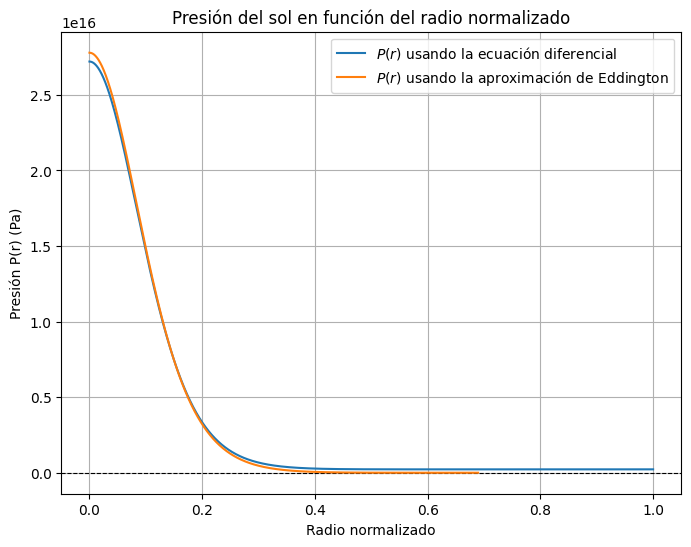

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Constantes en unidades SI
m_H = 1.67e-27   # kg (masa del protón)
c = 2.99792458e10  # m/s Velocidad de la luz
h = 6.62607004e-38 /2*np.pi # J s Constante de Plank reducida
G = 6.67430e-11  # m^3 kg^-1 s^-2
k = 3.337e9 #k = (1/2) * h * c * (3*(np.pi)**2)**1/3 * (1/(2*m_H))**(4/3)
# Cargar los datos de M(r) y rho(r) desde los archivos txt
r_vals = np.loadtxt("r_vals.txt")
rho_vals = np.loadtxt("rho_vals.txt")
M_vals = np.loadtxt("M_vals.txt")

# Crear interpolaciones suaves de M(r) y rho(r) para que los valores queden dentro la discretización en el RK4
M_interp = interp1d(r_vals, M_vals, kind='cubic', fill_value="extrapolate")
rho_interp = interp1d(r_vals, rho_vals, kind='cubic', fill_value="extrapolate")

# Definir la ecuación diferencial de la presión
def dP_dr(r, P):
    rho = rho_interp(r)
    M = M_interp(r)
    return -G * M * rho / r**2

# Método RK4 para la integración
def rk4_pressure(f, r0, P0, r_max, N):
    r_values = np.linspace(r0, r_max, N+1)
    P_values = np.zeros_like(r_values)
    P_values[0] = P0
    h = (r_max - r0) / N

    for i in range(N):

        k1 = h * f(r_values[i], P_values[i])
        k2 = h * f(r_values[i] + h/2, P_values[i] + k1/2)
        k3 = h * f(r_values[i] + h/2, P_values[i] + k2/2)
        k4 = h * f(r_values[i] + h, P_values[i] + k3)

        P_values[i+1] = P_values[i] + (k1 + 2*k2 + 2*k3 + k4) / 6

    return r_values[:i+2], P_values[:i+2]

# Parámetros iniciales
r0 = np.min(r_vals)  # Radio inicial
r_max = np.max(r_vals)  # Radio máximo basado en datos
P0 = 2.72e16  # Presión en el nucleo del sol, estimada en Pascales, obtenida de la bibliografia
N = 2000  # Número de pasos para mayor precisión

# Resolver la ecuación diferencial
r_solution, P_solution = rk4_pressure(dP_dr, r0, P0, r_max, N)

#Presión en la aproximación de Eddington

P_solution2 = k * rho_vals**(4/3)

# Graficas de la presión
plt.figure(figsize=(8,6))
plt.plot(r_solution/(10e6*r0), P_solution, label=r'$P(r)$ usando la ecuación diferencial')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(r_solution/(10e6*r0), P_solution2, label=r'$P(r)$ usando la aproximación de Eddington')
plt.xlabel('Radio normalizado')
plt.ylabel('Presión P(r) (Pa)')
plt.title('Presión del sol en función del radio normalizado')
plt.grid(True)
plt.legend()
plt.show()

np.savetxt("r_solution.txt", r_solution)
np.savetxt("P_solution.txt", P_solution)

Ambas graficas presentan el mismo perfil, no obstante, la grafica que se obtiene del modelo de Eddington, llega a un valor de 0 dentro de los margenes estipulados para el radio del sol, mientras que la obtenida de la ecuación diferencial no alcanza el valor de 0. Lo cual resulta algo extraño, pues sabemos que dada la continuidad de las funciones, la presión en la frontera del sol deberia ser 0.

#**Obtención de la temperatura usando la ecuación de estado para un modelo de gas ideal monoatómico clásico**

En este caso, supondremos que el sol sigue la ecuación de estado para un gas ideal monoatomico clasico. El objeivo será calcular la temperatura del sol en función del radio haciendo uso de este modelo. Para ello, tendremos en cuenta los dos resultados obtenidos para la presión.

*La ecuación de estado que usaremos es la siguiente:*

\begin{equation} T = \frac{\mu P(r) m_{H}}{\rho(r) k_{b}} \end{equation}

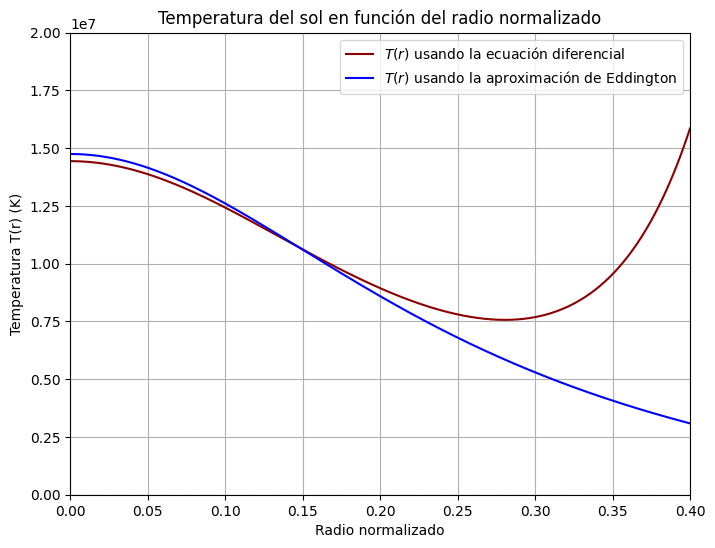

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes físicas
rho_vals = np.loadtxt("rho_vals.txt")
m_H = 1.67e-27   # kg (masa del protón)
mu = 1.36/2
K_b = 1.38e-23   # J/K (constante de Boltzmann)
#Temperatura en terminos de la presión que se obtiene al resolver la ecuación diferencial.
rho_vals[rho_vals == 0] = np.nan # Evitar divisiones por cero
T_vals = (mu * P_solution * m_H) / (rho_vals * K_b)
#Temperatura en terminos de la presión que se obtiene de la aproximacion de Eddington.
T_vals2 = (mu * P_solution2 * m_H) / (rho_vals * K_b)
# Grafica
plt.figure(figsize=(8,6))
plt.plot(r_vals/(10e6*r0), T_vals, label=r'$T(r)$ usando la ecuación diferencial', color='darkred')
plt.plot(r_vals/(10e6*r0), T_vals2, label=r'$T(r)$ usando la aproximación de Eddington', color='blue')
plt.axhline(0, color='r', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel('Temperatura T(r) (K)')
plt.xlim (0,0.4)
plt.ylim (0,2*10e6)
plt.title('Temperatura del sol en función del radio normalizado')
plt.grid(True)
plt.legend()
plt.show()


Aquí vemos las consecuencias de los resultados obtenidos en la presión, mientras que en el modelo Eddington, la temperatura decae de manera suave y sin cambios bruscos a medida que se acerca a la frontera del sol; en los resultados obtenidos mediante la solución de la ecuación diferencial, se presenta un cambio abrupto en los valores de la temperatura, esto debido a que la densidad tiende a 0, mientras que la presión no lo hace, en un punto cercano al 25% del radio solar.

#**Comparación con el Modelo Estandar del Sol**

In [ ]:
#Importamos los datos dados por el Profe en el archivo "BS2005 (AGS, OP).dat   BS2005 (OP).dat (astro-ph/0412440)"
from google.colab import files
uploaded = files.upload()


Saving Sun.txt to Sun.txt


In [ ]:
#Ordenar los datos del archivo "BS2005 (AGS, OP).dat   BS2005 (OP).dat (astro-ph/0412440)"
from google.colab import files
data = np.loadtxt('Sun.txt')
col1 = data[:, 0] #M/Msun (masa)
col2 = data[:, 1] #R/Rsun (radio)
col3 = data[:, 2] #T (temperatura)
col4 = data[:, 3] #rho (densidad)
col5 = data[:, 4] #P (presión)
r_sun = np.linspace(min(col2), max(col2), 2001)

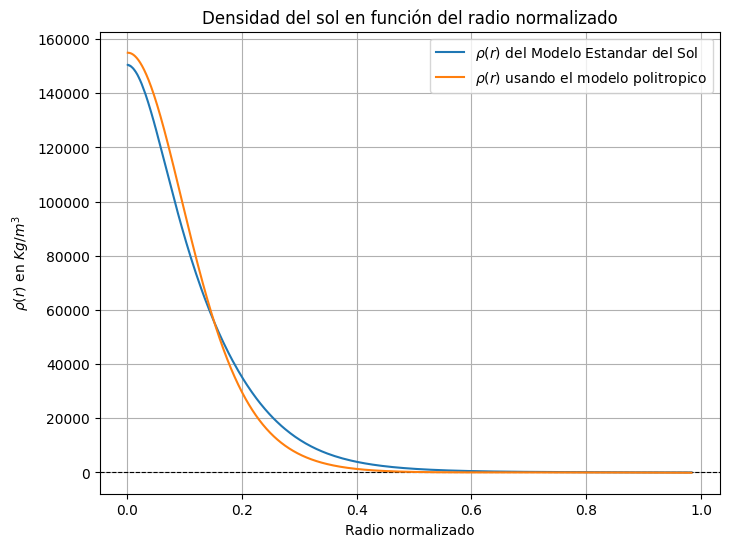

In [ ]:
rho_sun = np.interp(r_sun, col2, col4) #Interpolamos los valores de densidad en función de los valores de radio normalizado
#Graficas la densidad en función de r
"Todos los valores que se ven de potencias de 10, son para arreglar las unidades, dado que estamos trabajando en SI y los datos compartidos estan en otras unidades"
plt.figure(figsize=(8,6))
plt.plot(r_sun, rho_sun*10e2,label=r'$\rho(r)$ del Modelo Estandar del Sol')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(r_sun, rho_vals, label=r'$\rho(r)$ usando el modelo politropico')
plt.xlabel('Radio normalizado')
plt.ylabel(r'$\rho(r)$ en $Kg/m^3$')
plt.title('Densidad del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

Se puede observar que las dos graficas se corresponde en manera adecuada, aunque no exacta, ahí puntos de coincidencia y el mismo perfil en el descenso de la densidad.

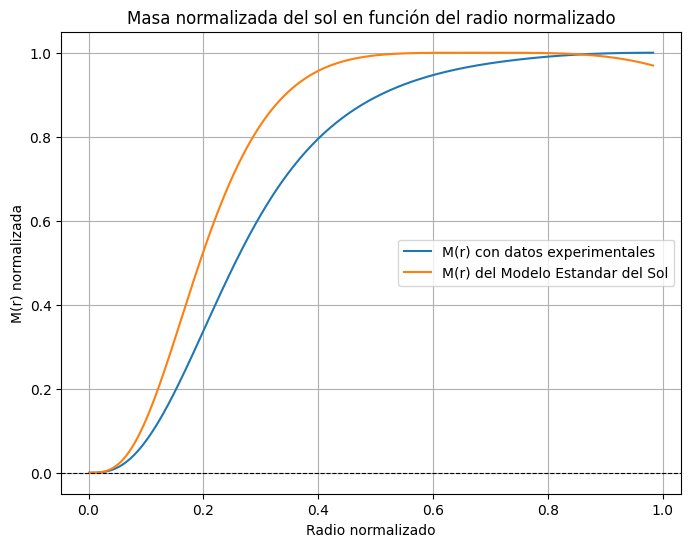

In [ ]:
M_sun = np.interp(r_sun, col2, col1) #Interpolamos los valores de la masa en función de los valores de radio normalizado
# Graficamos la masa en función de r
plt.figure(figsize=(8,6))
plt.plot(r_sun, M_sun,label=r'M(r) con datos experimentales')
plt.plot(r_sun, M_vals/max(M_vals), label=r'M(r) del Modelo Estandar del Sol') #para normalizar la masa
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel('M(r) normalizada')
plt.title('Masa normalizada del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

En los datos experimentales de la masa, se ve un crecimiento mas suave, mientras que en la simulación numerica, crece mas rapidamente en las partes mas cercanas al nucleo del sol, esto se debe quiza, a que en nuestro modelo, no se alcanza la masa completa del sol.

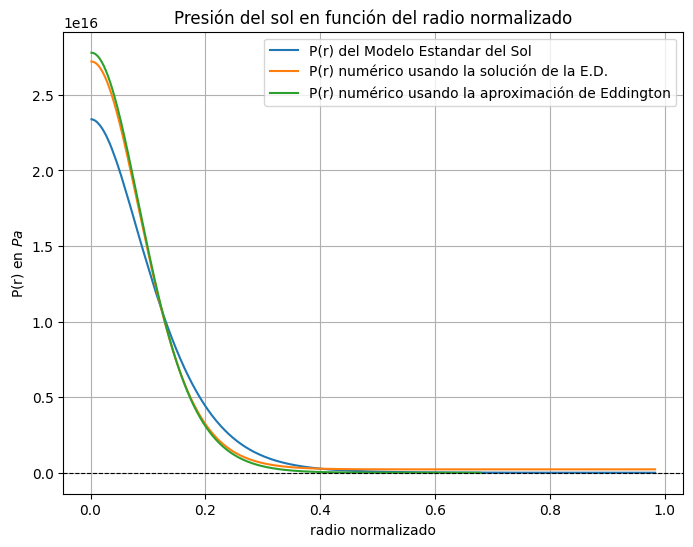

In [ ]:
P_sun = np.interp(r_sun, col2, col5)#Interpolamos los valores de la presión en función de los valores de radio normalizado
# Graficamos la presión en función de r
plt.figure(figsize=(8,6))
plt.plot(r_sun, P_sun/10,label=r'P(r) del Modelo Estandar del Sol')
plt.plot(r_sun, P_solution, label=r'P(r) numérico usando la solución de la E.D.')
plt.plot(r_sun, P_solution2, label=r'P(r) numérico usando la aproximación de Eddington')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('radio normalizado')
plt.ylabel(r'P(r) en $Pa$')
plt.title('Presión del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

Aquí se observa una diferencia en los valores inciales, mientras que en la bilbiografia, se estima que el valor en el centro del sol es de aprox 2.7 x $10^{16}$ Pa, es lo datos experimentales el valor es infeior a 2.5 x $10^{16}$ Pa, esto influye en el resultado final de la grafica, sin embargo, se observa un perfil similar en las mismas.

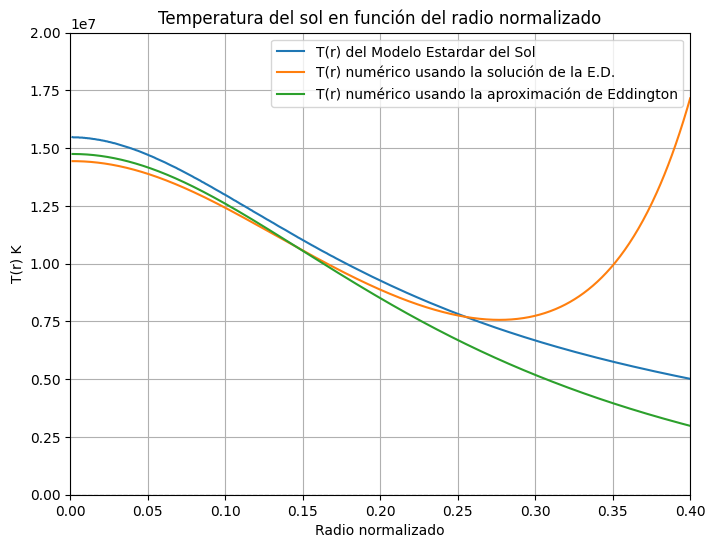

In [ ]:
T_sun = np.interp(r_sun, col2, col3)#Interpolamos los valores de la temperatura en función de los valores de radio normalizado
# Graficamos la temperatura en función de r
plt.figure(figsize=(8,6))
plt.plot(r_sun, T_sun,label=r'T(r) del Modelo Estardar del Sol')
plt.plot(r_sun, T_vals, label=r'T(r) numérico usando la solución de la E.D.')
plt.plot(r_sun, T_vals2, label=r'T(r) numérico usando la aproximación de Eddington')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel('T(r) K')
plt.title('Temperatura del sol en función del radio normalizado')
plt.xlim (0,0.4)
plt.ylim (0,2*10e6)
plt.legend()
plt.grid(True)
plt.show()

En nuestro modelo, la temperatura que se obtiene de los datos experimentales, solo es comparable con el modelo que usa la aproximación de Eddington, dado que el otro modelo tiene un aunmento abrupto. No obstante, con el modelo de Eddington si se logra un acercamiento al comportamiento real de la temperatura.

#Comparación con otro modelo Politropico.

Aqui compararemos los datos obtenidos computacionalmente con los datos que obtievon anteriormente en otro articulo donde se modelo al sol como un gas politropico, sin embargo, en el articulo usan resultados de la estadistica cuantica, por ende, nuestro objetivo aqui sera acercarnos de la mejor manera a dichos valores. Para sustraer los datos de dicho articulo se realizó una digitalización de las graficas que ahí se muestran, reescalando los valores a los datos que manejamos aquí.

In [ ]:
#Importamos los datos de densidad reescalados de otro modelo politropico.
from google.colab import files
uploaded = files.upload()

Saving DENSIDAD TEORICA1.txt to DENSIDAD TEORICA1.txt


In [ ]:
#Ordenar los datos del archivo
from google.colab import files
data = np.loadtxt('DENSIDAD TEORICA1.txt')
col1_new_d = data[:, 0] #R/Rsun (radio)
col2_new_d = data[:, 1] # densidad
r_sun_new_d = np.linspace(min(col1_new_d), max(col1_new_d), 2001)

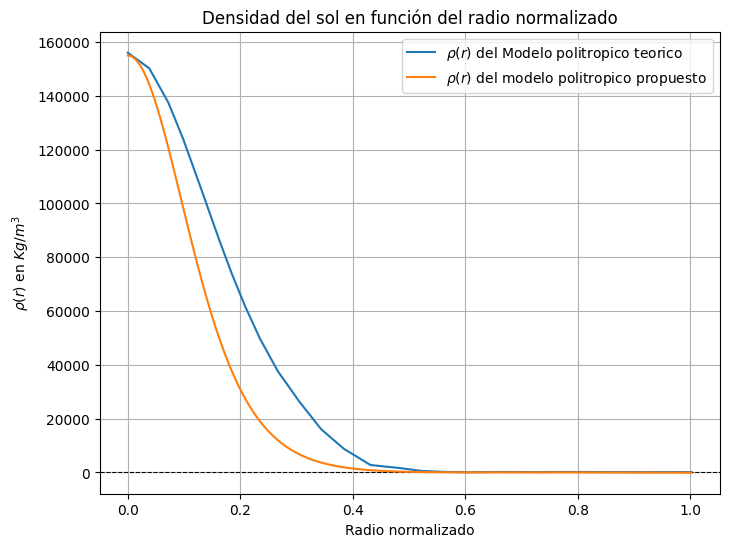

In [ ]:
rho_sun_new = np.interp(r_sun_new_d, col1_new_d, col2_new_d) #Interpolamos los valores de densidad en función de los valores de radio normalizado
#Graficas la densidad en función de r
"Todos los valores que se ven de potencias de 10, son para arreglar las unidades, dado que estamos trabajando en SI y los datos compartidos estan en otras unidades"
plt.figure(figsize=(8,6))
plt.plot(r_sun_new_d, rho_sun_new,label=r'$\rho(r)$ del Modelo politropico teorico')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(r_sun_new_d, rho_vals, label=r'$\rho(r)$ del modelo politropico propuesto')
plt.xlabel('Radio normalizado')
plt.ylabel(r'$\rho(r)$ en $Kg/m^3$')
plt.title('Densidad del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

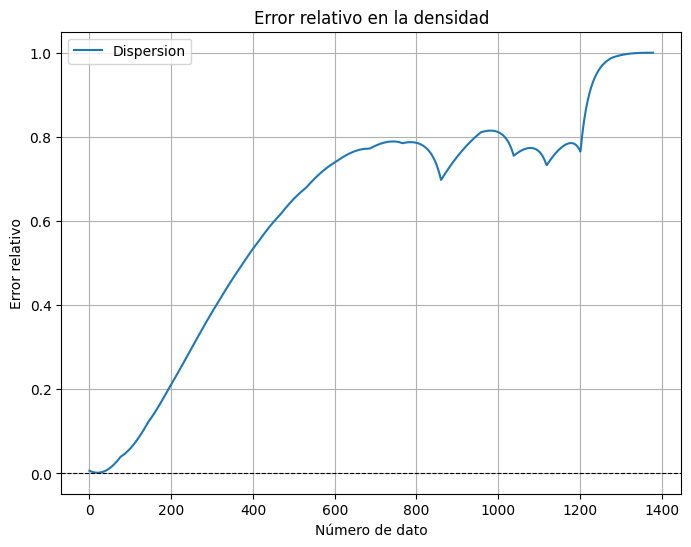

In [ ]:
dispersion_rho = abs((rho_sun_new) - rho_vals)/(rho_sun_new)
N_sun = np.arange(0,2001)
dispersion_rho[dispersion_rho>1] = np.nan
dispersion_rho[dispersion_rho<-1] = np.nan
plt.figure(figsize=(8,6))
plt.plot(N_sun, dispersion_rho, label=r'Dispersion')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Número de dato')
plt.ylabel('Error relativo')
plt.title('Error relativo en la densidad')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Importamos los datos de presion reescalados de otro modelo politropico.
from google.colab import files
uploaded = files.upload()

Saving datos tempe.txt to datos tempe.txt


In [ ]:
#Ordenar los datos del archivo
from google.colab import files
data = np.loadtxt('datos tempe.txt')
col1_new = data[:, 0] #R/Rsun (radio)
col2_new = data[:, 1] # presion
r_sun_new = np.linspace(min(col1_new), max(col1_new), 2001)

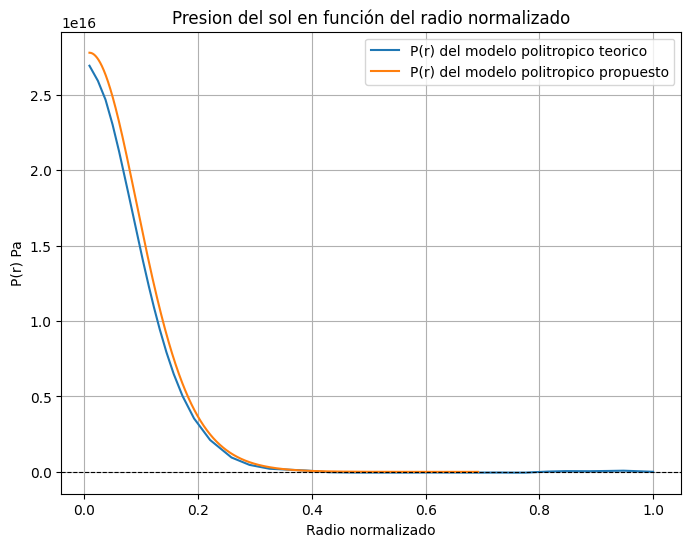

In [ ]:
P_sun_new = np.interp(r_sun_new, col1_new, col2_new)#Interpolamos los valores de la presion en función de los valores de radio normalizado
# Graficamos la temperatura en función de r
plt.figure(figsize=(8,6))
plt.plot(r_sun_new, P_sun_new*10e8,label=r'P(r) del modelo politropico teorico')
plt.plot(r_sun_new, P_solution2, label=r'P(r) del modelo politropico propuesto')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel('P(r) Pa')
plt.title('Presion del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

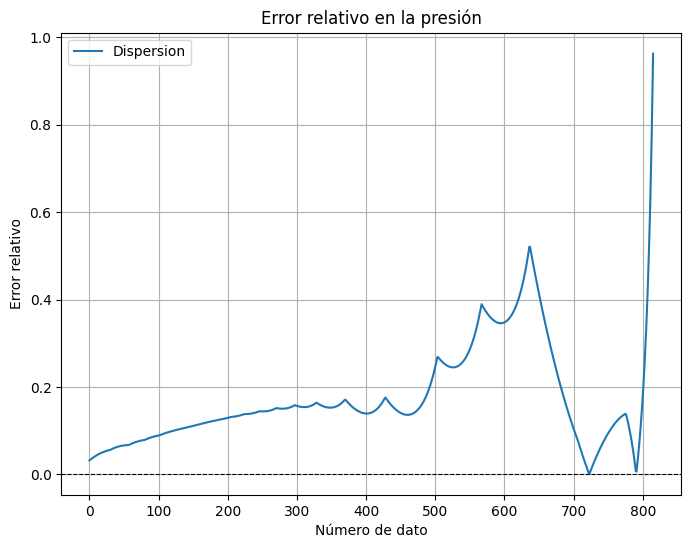

In [ ]:
dispersion_P = abs((P_sun_new*10e8) - P_solution2)/(P_sun_new*10e8)
dispersion_P[dispersion_P>1] = np.nan
dispersion_P[dispersion_P<-1] = np.nan
plt.figure(figsize=(8,6))
plt.plot(N_sun, dispersion_P, label=r'Dispersion')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Número de dato')
plt.ylabel('Error relativo')
plt.title('Error relativo en la presión')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
#Importamos los datos de temperatura reescalados de otro modelo politropico.
from google.colab import files
uploaded = files.upload()

Saving TEMPERATURA TEORICA.txt to TEMPERATURA TEORICA.txt


In [ ]:
#Ordenar los datos del archivo
from google.colab import files
data = np.loadtxt('TEMPERATURA TEORICA.txt')
col1_new_T = data[:, 0] #R/Rsun (radio)
col2_new_T = data[:, 1] #T
r_sun_new_T = np.linspace(min(col1_new_T), max(col1_new_T), 2001)

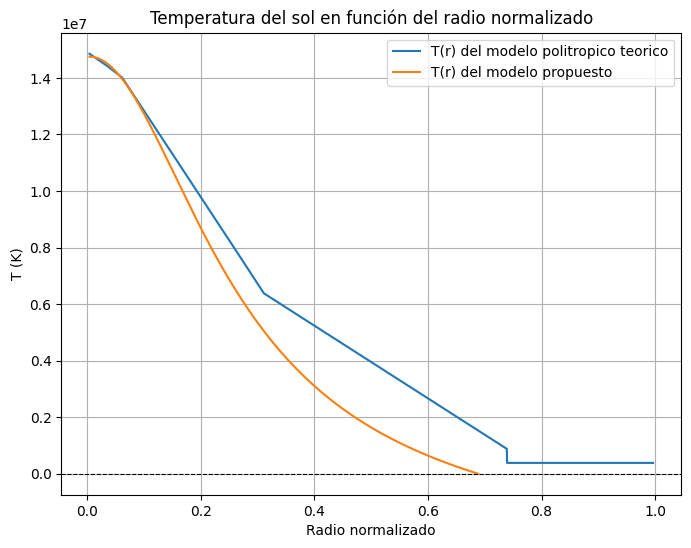

In [ ]:
T_sun_new = np.interp(r_sun_new_T, col1_new_T, col2_new_T)#Interpolamos los valores de la presion en función de los valores de radio normalizado
# Graficamos la temperatura en función de r
plt.figure(figsize=(8,6))
plt.plot(r_sun_new_T, T_sun_new,label=r'T(r) del modelo politropico teorico')
plt.plot(r_sun_new_T, T_vals2, label=r'T(r) del modelo propuesto')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel('T (K)')
plt.title('Temperatura del sol en función del radio normalizado')
plt.legend()
plt.grid(True)
plt.show()

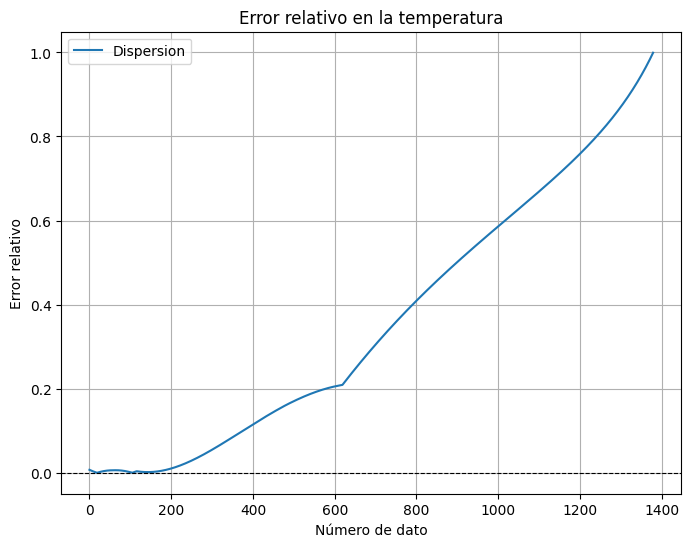

In [ ]:
dispersion_T = abs((T_sun_new) - T_vals2)/(T_sun_new)
dispersion_T[dispersion_T>1] = np.nan
dispersion_T[dispersion_T<-1] = np.nan
plt.figure(figsize=(8,6))
plt.plot(N_sun, dispersion_T, label=r'Dispersion')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Número de dato')
plt.ylabel('Error relativo')
plt.title('Error relativo en la temperatura')
plt.legend()
plt.grid(True)
plt.show()

#**Implementación del modelo para una enana blanca**

La enanas blancas hacen parte de la rama princiapal dentro de la evolución estelar. Resultan ser objetos muy interesantes de estudiar dentro de la estadistica clasica, como cuantica. Continuando con el proceso de evolución estelar, se tiene que, una estrella de tamañoo medio como el Sol, tras la fase de gigante roja, continua con el colapso gravitatorio una vez agotado el combustible que frenaba este colapso. La estrella entonces se contrae hasta que aparece una nueva presión, que no se debe a las reacciones nucleares, si no que
opera a densidades mucho más altas, deteniendo el proceso. Así comienza la fase de enana blanca.

En estos cuerpos celestes las reacciones termonucleares ocurren muy lentamente, por ello son mucho menos calientes de lo que uno esperaría por su color blanco. El componente principal de las enanas blancas es el helio, carbono y oxígeno. Una típica enana blanca de la masa del Sol, tendría un tamaño aproximadamente igual al de la Tierra. Son objetos muy densos.

Por lo anterior el radio del sol como enana blanca será aproximadamente $R = 6300$ $Km$, que en terminos del radio solar será:
\begin{equation}
\frac{R_{\oplus}}{R_{\odot}} = \frac{6371 \,\text{km}}{695700 \,\text{km}} \approx 0.0092 R
\end{equation}

Con esto podemos encontrar la densidad en el centro del sol como enana blanca mediante la expresión:

\begin{equation}
\mathcal{M} = \frac{\pi}{2} \rho_o R'^3
\end{equation}
Donde $R' \approx 0.0092 R$
Por tanto:
\begin{equation}
\rho_{0} = \frac{2\mathcal{M}}{\pi R'^3} ≈ 4.92 * 10^{18} \frac{Kg}{Km^3} ≈ 4.92*10^{9} \frac{Kg}{m^3}
\end{equation}


Anteriormente, observamos que el modelo que mejor se ajustaba a los valores teoricos del Sol era para n = 3, esto guiados por el articulo compartido por el profe. En este caso, no sabemos aún cual es el n que mejor podría reproducir el proceso de una enana blanca, por ende, reproduciremos los calculos hechos para el sol, pero con las condiciones iniciales encontradas para el sol como enana blanca para diferentes valores de n, y analizaremos aquellos que tengan mas sentido físico.

El nuevo valor para \begin{equation}  r_{0}=\left ( \frac{K}{\pi G\rho_{0}^{2/3}}  \right )^{1/2} = 2.3455e^{6} \end{equation}



#Grafica $\rho(r)$ para distintos valores de n



<ipython-input-26-4c54d7868592>:15: RuntimeWarning: invalid value encountered in power
  rho_vals_n = rhoe0 * (theta_vals ** n0)


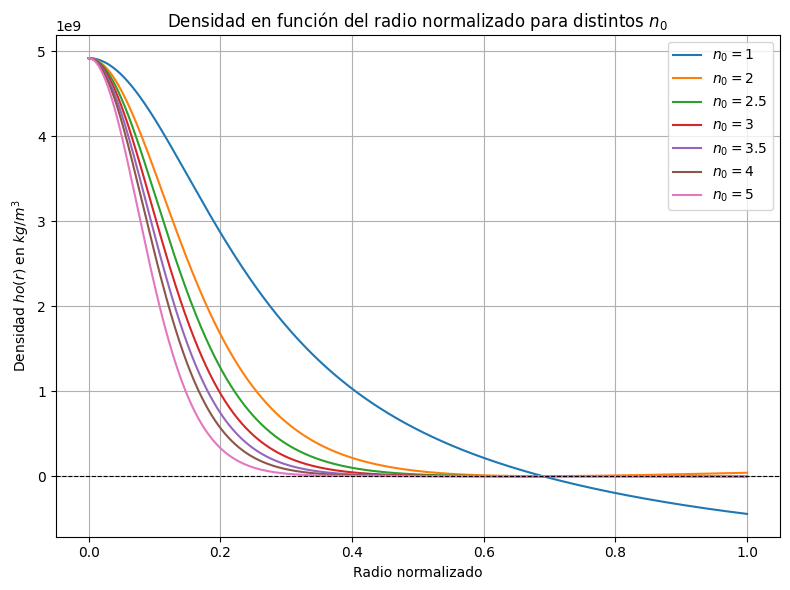

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos valores iniciales
r0_new = 2.3455e6
rhoe0 = 4.92e9   # Densidad núcleo enana blanca
n_values = [1, 2, 2.5, 3, 3.5, 4, 5]  # Valores de n0

plt.figure(figsize=(8,6))

# Iteramos para cada valor de n0
data = {}
for n0 in n_values:
    r_vals_n = x_vals * r0_new
    rho_vals_n = rhoe0 * (theta_vals ** n0)

    # Guardamos datos
    data[f"r_vals_n{n0}"] = r_vals_n
    data[f"rho_vals_n{n0}"] = rho_vals_n

    # Graficamos cada curva
    plt.plot(r_vals_n / (10 * r0_new), rho_vals_n, label=fr'$n_0={n0}$')

    # Guardamos los valores en archivos
    np.savetxt(f"r_vals_n{n0}.txt", r_vals_n)
    np.savetxt(f"rho_vals_n{n0}.txt", rho_vals_n)

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel(r'Densidad $ho(r)$ en $kg/m^3$')
plt.title('Densidad en función del radio normalizado para distintos $n_0$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Aqui se obsserva que las graficas que tienen mas sentido físico, son aquellas que se obtienen para n = 2 en adelante, para valores menores de 2, las densidades se vuelven negativas, lo cual no tiene sentido físico.

#Grafica $P(r)$ para distintos valores de n

Aquí usaremos el modelo bajo la aproximación de Eddington

<ipython-input-27-70edf11d2b71>:8: RuntimeWarning: invalid value encountered in power
  P_solution2_n = k * rho_vals_n**(4/3)


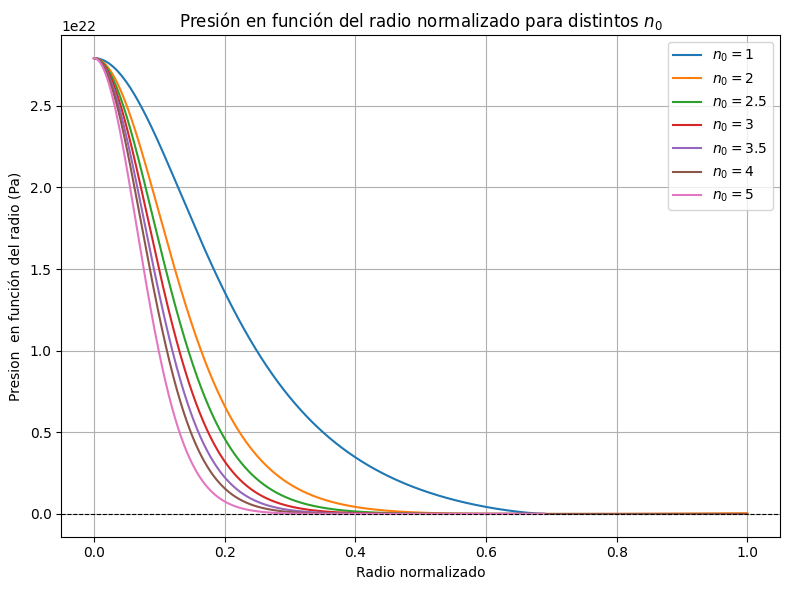

In [ ]:
# Iteramos para cada valor de n0
plt.figure(figsize=(8,6))
data = {}
for n0 in n_values:
    rho_vals_n = np.loadtxt(f"rho_vals_n{n0}.txt")
    r_vals_n = np.loadtxt(f"r_vals_n{n0}.txt")
    #r_vals_n = x_vals * r0
    P_solution2_n = k * rho_vals_n**(4/3)

    # Guardamos datos
    data[f"r_vals_n{n0}"] = r_vals_n
    data[f"P_vals_n{n0}"] = P_solution2_n

    # Graficamos cada curva
    plt.plot(r_vals_n / (10 * r0_new), P_solution2_n, label=fr'$n_0={n0}$')

    # Guardamos los valores en archivos
    np.savetxt(f"r_vals_n{n0}.txt", r_vals_n)
    np.savetxt(f"P_vals_n{n0}.txt", P_solution2_n)

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel(r'Presion  en función del radio (Pa)')
plt.title('Presión en función del radio normalizado para distintos $n_0$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


En este caso, la presión tiene sentido físico para en todos los valores de n, no obstante, a medida que el n es mayor, se ve un descenso mas pronunciado de la presión.

#Grafica $T(r)$ para distintos valores de n

Usamos la ecuación de estado:

\begin{equation} T = \frac{\mu P(r) m_{H}}{\rho(r) k_{b}} \end{equation}

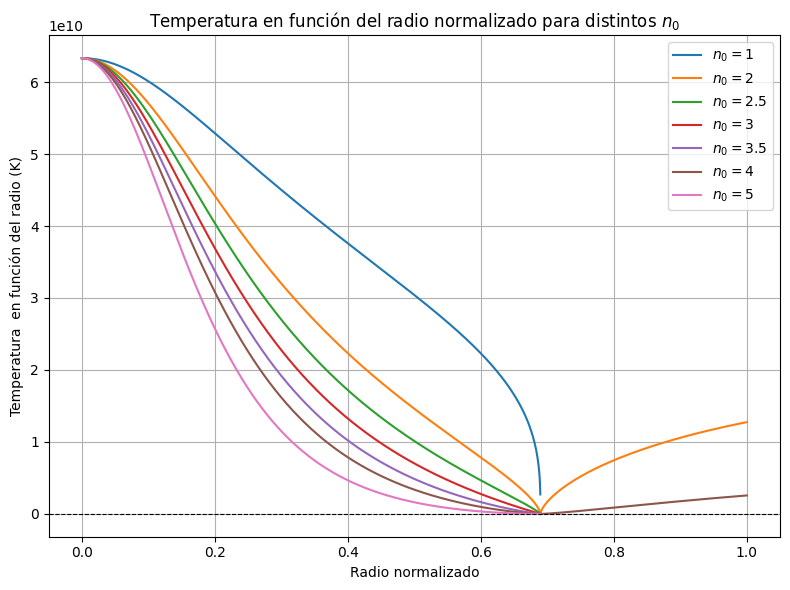

In [ ]:
#Iteramos para cada valor de n0
mu1 = 92.2
plt.figure(figsize=(8,6))
data = {}
for n0 in n_values:
    p_vals_n = np.loadtxt(f"P_vals_n{n0}.txt")
    rho_vals_n = np.loadtxt(f"rho_vals_n{n0}.txt")
    r_vals_n = np.loadtxt(f"r_vals_n{n0}.txt")
    r_vals_n = x_vals * r0_new
    T_vals2_n = (mu1 * p_vals_n * m_H) / (rho_vals_n * K_b)

    # Guardamos datos
    data[f"r_vals_n{n0}"] = r_vals_n
    data[f"T_vals_n{n0}"] = T_vals2_n

    # Graficamos cada curva
    plt.plot(r_vals_n / (10 * r0_new), T_vals2_n, label=fr'$n_0={n0}$')

    # Guardamos los valores en archivos
    np.savetxt(f"r_vals_n{n0}.txt", r_vals_n)
    np.savetxt(f"T_vals_n{n0}.txt", T_vals2_n)

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel(r'Temperatura  en función del radio (K)')
plt.title('Temperatura en función del radio normalizado para distintos $n_0$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Pa los valores de n = 1, 2, 5 la grafica de temperatura no tiene mucho sentido físico, así que, el valor apropiado debería estar en el intervalo n = (2, 5),esto ya nos da una señal para cuando queramos implementar el modelo con estadistica cuantica y contrastarlo co  valores experimentales. Tambien se puede ver que la temperatura en el centro de unan enana blanca, es mucho mayor a la temperatura en el centro del sol actual.

# Temperatura para la estadistica de Fermi Dirac

En el caso de las enanas blancas, el unico resultado que se verá afectado cuando consideremos la ecuación de estado obtenida de la estadistica de Fermi-Dirac, será la temperatura. Donde esta ultima vendrá dada por la ecuación:


\begin{equation}
T(P, \rho) \approx \frac{\mu m_H P}{\rho k_B}
- \frac{1}{2^{3/2}} g \left( \frac{2\pi \hbar^2}{\mu m_H k_B} \right)^{3/2}
\frac{\rho^{3/2}}{(\mu m_H)^2} \cdot \frac{1}{\sqrt{P/(n k_B)}}
+ \mathcal{O}\left((\Lambda^3 n)^2\right)
\end{equation}


<ipython-input-29-fd0323ac032d>:19: RuntimeWarning: invalid value encountered in power
  term2 *= (rho_vals_n**(3/2)) / (mu1 * m_H)**2


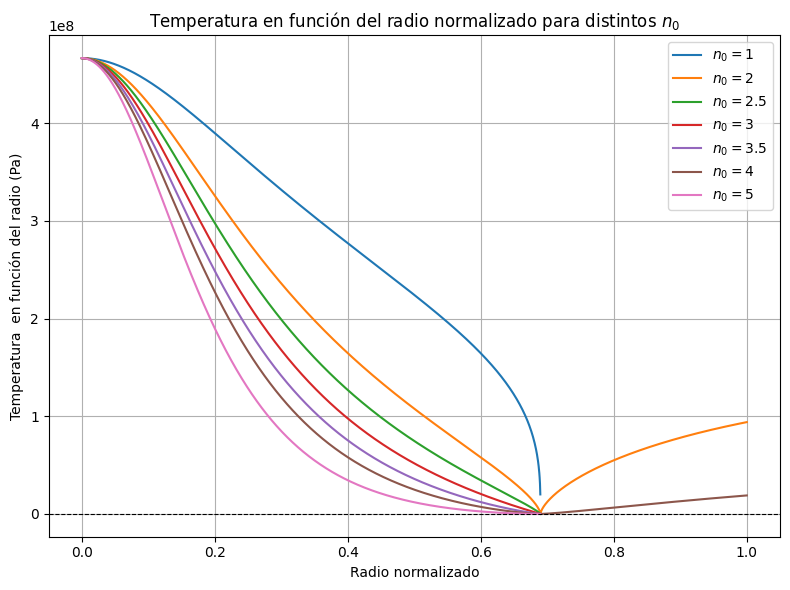

In [ ]:
# Constantes físicas (puedes ajustar según sea necesario)
hbar = 1.0545718e-34   # Constante de Planck reducida (J·s)
k_B = 1.380649e-23     # Constante de Boltzmann (J/K)
mu1 = 92.2
g = 6.67430e-11  # Constante de gravitación universal (m^3/kg/s^2)
# Iteramos para cada valor de n0
plt.figure(figsize=(8,6))
data = {}
for n0 in n_values:
    p_vals_n = np.loadtxt(f"P_vals_n{n0}.txt")
    rho_vals_n = np.loadtxt(f"rho_vals_n{n0}.txt")
    r_vals_n = np.loadtxt(f"r_vals_n{n0}.txt")
    r_vals_n = x_vals * r0_new
    # Término principal
    term1 = (mu * m_H * p_vals_n) / (rho_vals_n * k_B)

    # Corrección cuántica
    term2 = (1 / (2**(3/2))) * g * ((2 * np.pi * hbar**2) / (mu * m_H * k_B))**(3/2)
    term2 *= (rho_vals_n**(3/2)) / (mu1 * m_H)**2
    term2 *= 1 / np.sqrt(p_vals_n / (n * k_B))

    # Temperatura aproximada
    T_n = term1 - term2

    # Guardamos datos
    data[f"r_vals_n{n0}"] = r_vals_n
    data[f"T_n{n0}"] = T_n

    # Graficamos cada curva
    plt.plot(r_vals_n / (10 * r0_new), T_n, label=fr'$n_0={n0}$')

    # Guardamos los valores en archivos
    np.savetxt(f"r_vals_n{n0}.txt", r_vals_n)
    np.savetxt(f"T_n{n0}.txt", T_n)

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Radio normalizado')
plt.ylabel(r'Temperatura  en función del radio (Pa)')
plt.title('Temperatura en función del radio normalizado para distintos $n_0$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Intento Isocontornos

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
#plt.style.use('seaborn-white')
import numpy as np

In [ ]:
import numpy as np

dens = np.array(rho_vals)
# Asegúrate de que la longitud sea múltiplo de 200; si no, recorta o rellena antes:
dens = dens[:2000]
dens_reshaped = dens.reshape(-1, 200)      # se convierte en matriz de forma (10, 200)
rho_prom = dens_reshaped.mean(axis=1)  # media de cada fila

print(rho_prom)  # array de 10 promedios
print(len(rho_vals))

[ 1.33451616e+05  5.99877314e+04  1.64974169e+04  3.62221326e+03
  6.58866803e+02  7.98407431e+01  2.70302433e+00 -3.03861332e+00
 -2.71833461e+01 -7.99786474e+01]
2001


In [ ]:
import numpy as np

presion = np.array(P_solution)
# Asegúrate de que la longitud sea múltiplo de 200; si no, recorta o rellena antes:
presion = presion[:2000]
presion_reshaped = presion.reshape(-1, 200)      # se convierte en matriz de forma (10, 200)
pres_prom = presion_reshaped.mean(axis=1)  # media de cada fila

print(pres_prom)

[2.24093890e+16 8.00716614e+15 1.63270226e+15 4.10369367e+14
 2.41699052e+14 2.23250451e+14 2.22033572e+14 2.22034417e+14
 2.22292403e+14 2.23147503e+14]


In [ ]:
def f(x,y):
    return y*m_H*mu/(x*K_b)
y = np.linspace(-0.1,0.1,50)
x = np.linspace(-0.1,0.1,50)

In [ ]:
X,Y= np.meshgrid(x,y)
#print(X)
#print(Y)
Z = f(X,Y)
print(Z)

[[ 8.22898551e-05  8.57915510e-05  8.96045089e-05 ... -8.96045089e-05
  -8.57915510e-05 -8.22898551e-05]
 [ 7.89310855e-05  8.22898551e-05  8.59471820e-05 ... -8.59471820e-05
  -8.22898551e-05 -7.89310855e-05]
 [ 7.55723159e-05  7.87881591e-05  8.22898551e-05 ... -8.22898551e-05
  -7.87881591e-05 -7.55723159e-05]
 ...
 [-7.55723159e-05 -7.87881591e-05 -8.22898551e-05 ...  8.22898551e-05
   7.87881591e-05  7.55723159e-05]
 [-7.89310855e-05 -8.22898551e-05 -8.59471820e-05 ...  8.59471820e-05
   8.22898551e-05  7.89310855e-05]
 [-8.22898551e-05 -8.57915510e-05 -8.96045089e-05 ...  8.96045089e-05
   8.57915510e-05  8.22898551e-05]]


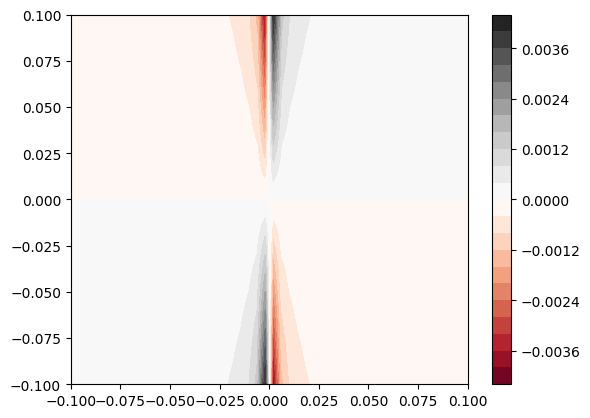

In [ ]:
plt.contourf(X, Y, Z, 20, cmap='RdGy')
plt.colorbar();